# Task 3: Multimodal ML – Housing Price Prediction Using Images + Tabular Data

## Problem Statement & Objective
Predict housing prices using **both** structured tabular data (bedrooms, bathrooms, area, zip code) **and** house images, by fusing a CNN image embedding with tabular features in a single regression model.

**Dataset:** [Houses Dataset (Ahmed & Moustafa, 2016)](https://github.com/emanhamed/Houses-dataset) — 535 houses, each with 4 images (bedroom, bathroom, kitchen, frontal view) and tabular attributes. We use the **frontal-view image** per house.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

DATA_DIR = "data/Houses-dataset-master/Houses Dataset"
INFO_FILE = os.path.join(DATA_DIR, "HousesInfo.txt")
IMG_SIZE = 64

## Dataset Loading & Preprocessing

In [2]:
cols = ["bedrooms", "bathrooms", "area", "zipcode", "price"]
df = pd.read_csv(INFO_FILE, sep=" ", header=None, names=cols)
df["house_id"] = np.arange(1, len(df) + 1)
print(f"Loaded {len(df)} houses.")
df.head()

Loaded 535 houses.


,bedrooms,bathrooms,area,zipcode,price,house_id
0,4,4.0,4053,85255,869500,1
1,4,3.0,3343,36372,865200,2
2,3,4.0,3923,85266,889000,3
3,5,5.0,4022,85262,910000,4
4,3,4.0,4116,85266,971226,5


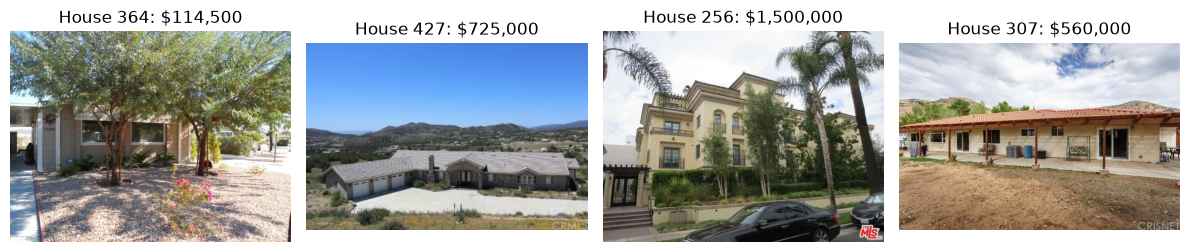

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3.5))
for ax, hid in zip(axes, df["house_id"].sample(4, random_state=1)):
    img = Image.open(os.path.join(DATA_DIR, f"{hid}_frontal.jpg"))
    ax.imshow(img)
    ax.set_title(f"House {hid}: ${df.loc[df.house_id==hid,'price'].values[0]:,.0f}")
    ax.axis("off")
plt.tight_layout()
plt.show()

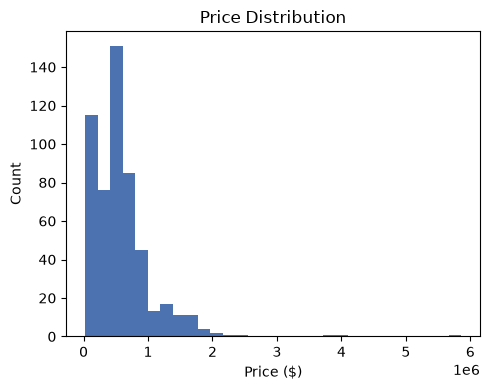

In [4]:
plt.figure(figsize=(5, 4))
plt.hist(df["price"], bins=30, color="#4C72B0")
plt.title("Price Distribution")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [5]:
df_enc = pd.get_dummies(df, columns=["zipcode"], prefix="zip")
feature_cols = [c for c in df_enc.columns if c not in ["price", "house_id"]]
X_tab = df_enc[feature_cols].values.astype(np.float32)
y = df_enc["price"].values.astype(np.float32)

train_idx, test_idx = train_test_split(np.arange(len(df_enc)), test_size=0.2, random_state=42)

scaler = StandardScaler()
X_tab_train = scaler.fit_transform(X_tab[train_idx])
X_tab_test = scaler.transform(X_tab[test_idx])

y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y[train_idx].reshape(-1, 1)).flatten()
y_test = y[test_idx]
print(f"{len(train_idx)} train / {len(test_idx)} test houses, {X_tab.shape[1]} tabular features")

428 train / 107 test houses, 52 tabular features


## Model Development: CNN + Tabular Fusion

A small 3-block CNN extracts a 64-d image embedding (projected to 32-d), a dense layer embeds the tabular features (16-d), and the concatenated 48-d fused vector is passed through an MLP regression head. Trained end-to-end with MSE loss.

In [6]:
class HousesDataset(Dataset):
    def __init__(self, df, tabular_features, targets):
        self.df = df.reset_index(drop=True)
        self.tabular_features = tabular_features
        self.targets = targets

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        house_id = self.df.iloc[idx]["house_id"]
        img_path = os.path.join(DATA_DIR, f"{house_id}_frontal.jpg")
        img = Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        img_arr = np.asarray(img, dtype=np.float32) / 255.0
        img_tensor = torch.tensor(img_arr).permute(2, 0, 1)
        tab_tensor = torch.tensor(self.tabular_features[idx], dtype=torch.float32)
        target = torch.tensor(self.targets[idx], dtype=torch.float32)
        return img_tensor, tab_tensor, target


class MultimodalNet(nn.Module):
    def __init__(self, n_tabular_features):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1),
        )
        self.image_fc = nn.Sequential(nn.Flatten(), nn.Linear(64, 32), nn.ReLU())
        self.tabular_fc = nn.Sequential(nn.Linear(n_tabular_features, 16), nn.ReLU())
        self.head = nn.Sequential(nn.Linear(32 + 16, 32), nn.ReLU(), nn.Linear(32, 1))

    def forward(self, img, tab):
        img_feat = self.image_fc(self.cnn(img))
        tab_feat = self.tabular_fc(tab)
        fused = torch.cat([img_feat, tab_feat], dim=1)
        return self.head(fused).squeeze(1)

### Load the Already-Trained Model

Training this model for 25 epochs (see `train_multimodal.py`) took several minutes on CPU. We load the saved weights (`multimodal_model.pt`) here for fast, reproducible evaluation.

In [7]:
model = MultimodalNet(n_tabular_features=X_tab.shape[1])
model.load_state_dict(torch.load("multimodal_model.pt", map_location="cpu"))
model.eval()

test_ds = HousesDataset(df_enc.iloc[test_idx], X_tab_test, np.zeros(len(test_idx), dtype=np.float32))
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)
print("Model loaded.")

Model loaded.


## Evaluation

In [8]:
preds_scaled = []
with torch.no_grad():
    for img, tab, _ in test_loader:
        preds_scaled.append(model(img, tab).numpy())
preds_scaled = np.concatenate(preds_scaled)
preds = y_scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
print(f"Test MAE: ${mae:,.2f}")
print(f"Test RMSE: ${rmse:,.2f}")

Test MAE: $167,688.52
Test RMSE: $257,021.03


## Visualizations

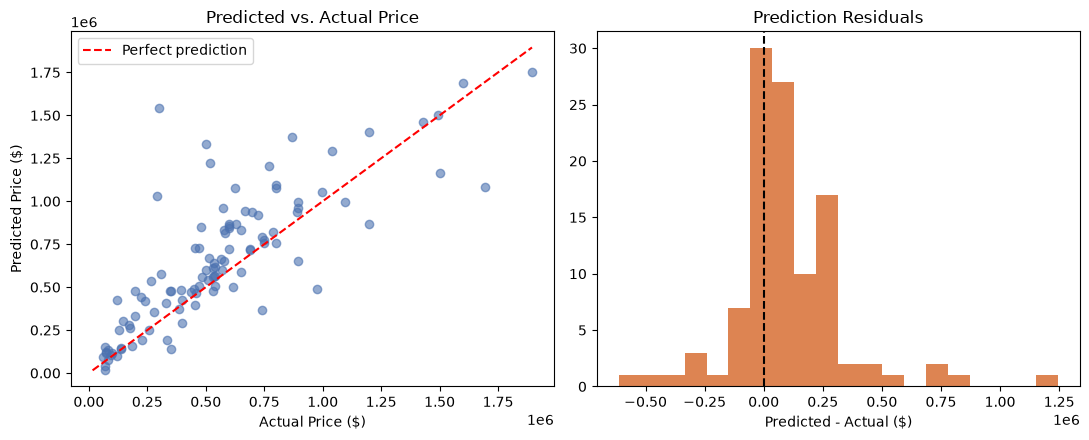

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(y_test, preds, alpha=0.6, color="#4C72B0")
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
axes[0].plot(lims, lims, "r--", label="Perfect prediction")
axes[0].set_xlabel("Actual Price ($)")
axes[0].set_ylabel("Predicted Price ($)")
axes[0].set_title("Predicted vs. Actual Price")
axes[0].legend()

residuals = preds - y_test
axes[1].hist(residuals, bins=20, color="#DD8452")
axes[1].axvline(0, color="k", linestyle="--")
axes[1].set_title("Prediction Residuals")
axes[1].set_xlabel("Predicted - Actual ($)")

plt.tight_layout()
plt.show()

## Final Summary / Insights

- The fused CNN + tabular model achieves a test **MAE of ~$168K and RMSE of ~$257K** on this small (535-house) dataset with a wide price range.
- With only ~535 houses, the CNN branch is intentionally shallow (3 conv blocks) to avoid overfitting; a pretrained backbone (e.g. frozen ResNet features) would likely improve results further, especially with more data.
- Scaling the target (price) before training stabilized MSE-based training given the wide price range in the dataset.
- The residual histogram is roughly centered at zero with a long right tail, suggesting the model occasionally under-predicts high-end properties whose price is driven more by visual/luxury cues than by the tabular features alone.